In [1]:
import os
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
ROOT = os.path.dirname(os.getcwd())
DB_PATH = os.path.join(ROOT, 'backend', 'db.sqlite3')
QUESTION_STATS = os.path.join(ROOT, 'statistics', 'stats_questions.csv')
ANSWER_STATS = os.path.join(ROOT, 'statistics', 'stats_answers.csv')

ROOT, DB_PATH, QUESTION_STATS, ANSWER_STATS

('D:\\Users\\thebr\\Documents\\Python-középhaladó\\zv',
 'D:\\Users\\thebr\\Documents\\Python-középhaladó\\zv\\backend\\db.sqlite3',
 'D:\\Users\\thebr\\Documents\\Python-középhaladó\\zv\\statistics\\stats_questions.csv',
 'D:\\Users\\thebr\\Documents\\Python-középhaladó\\zv\\statistics\\stats_answers.csv')

In [3]:
questions_stats = pd.read_csv(QUESTION_STATS)
answers_stats = pd.read_csv(ANSWER_STATS)

questions_stats.head(), answers_stats.head()

(   question_id  total_attempts  correct_attempts
 0            4               3                 1
 1            1               3                 2
 2            2               3                 1
 3            3               3                 1,
    question_id  answer_id  count
 0            4         13      1
 1            1          1      2
 2            2          5      1
 3            3          9      1
 4            1          4      1)

In [4]:
conn = sqlite3.connect(DB_PATH)

questions_data = pd.read_sql_query(
    'SELECT id, text FROM quiz_question',
    conn
)

answers_data = pd.read_sql_query(
    'SELECT id, text, is_correct, question_id FROM quiz_answer',
    conn
)

conn.close()

questions_data.head(), answers_data.head()

(   id                                    text
 0   1  Melyik kontinensen található Egyiptom?
 1   2            Melyik ország fővárosa Lima?
 2   3    Melyik Magyarország legnagyobb tava?
 3   4               Mi Magyarország fővárosa?,
    id        text  is_correct  question_id
 0   1      Afrika           1            1
 1   2      Európa           0            1
 2   3       Ázsia           0            1
 3   4  Ausztrália           0            1
 4   5        Peru           1            2)

In [5]:
questions = questions_stats.merge(
    questions_data,
    left_on='question_id',
    right_on='id'
).set_index('question_id')

answers = answers_stats.merge(
    answers_data,
    left_on='answer_id',
    right_on='id'
).drop(columns=['question_id_y']).rename(columns={'question_id_x': 'question_id'}).set_index('answer_id')

questions, answers

(             total_attempts  correct_attempts  id  \
 question_id                                         
 4                         3                 1   4   
 1                         3                 2   1   
 2                         3                 1   2   
 3                         3                 1   3   
 
                                                text  
 question_id                                          
 4                         Mi Magyarország fővárosa?  
 1            Melyik kontinensen található Egyiptom?  
 2                      Melyik ország fővárosa Lima?  
 3              Melyik Magyarország legnagyobb tava?  ,
            question_id  count  id          text  is_correct
 answer_id                                                  
 13                   4      1  13      Budapest           1
 1                    1      2   1        Afrika           1
 5                    2      1   5          Peru           1
 9                    3      1   9    

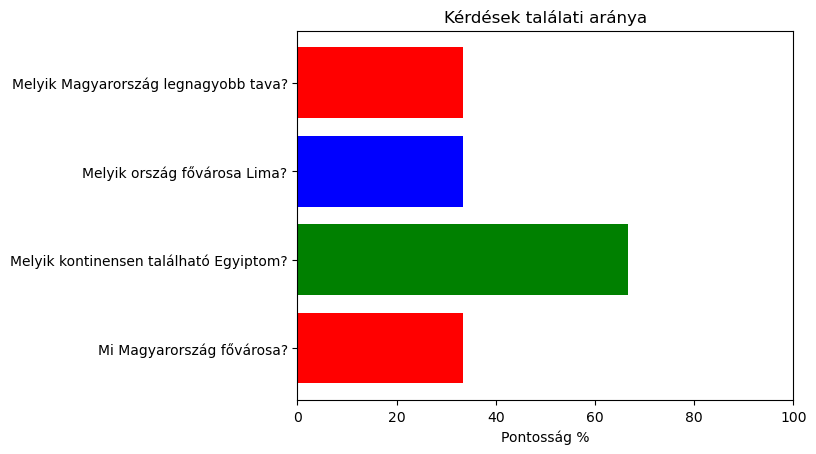

In [6]:
questions['accuracy'] = questions['correct_attempts'] / questions['total_attempts'] * 100

plt.barh(questions['text'], questions['accuracy'], color=['red', 'green', 'blue'])
plt.xlabel('Pontosság %')
plt.xlim(0, 100)
plt.title('Kérdések találati aránya')

plt.show()

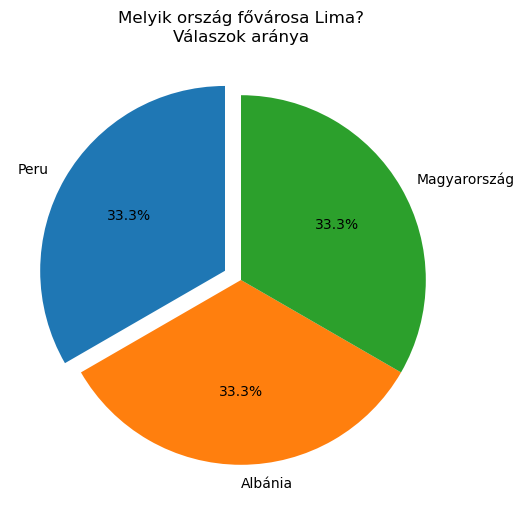

In [7]:
qid = 2
subset = answers[answers['question_id'] == qid]

plt.figure(figsize=(6,6))
plt.pie(
    subset['count'],
    labels=subset['text'],
    autopct='%1.1f%%',
    explode=(subset['is_correct'] == 1) * 0.1,
    startangle=90
)
plt.title(f'{questions.at[qid, 'text']}\nVálaszok aránya')
plt.show()